In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = sns.load_dataset("titanic")

In [4]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

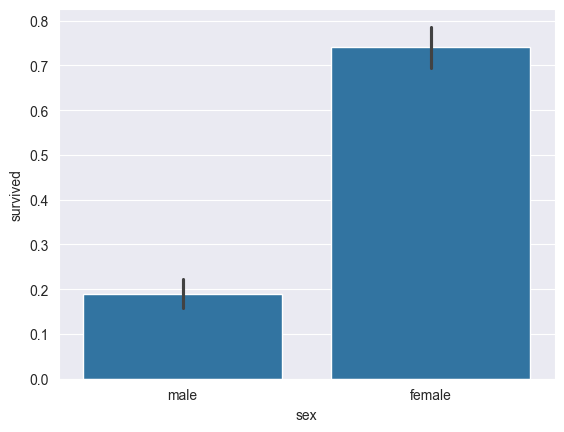

In [7]:
sns.barplot(data=data, x="sex", y="survived")
plt.show()

In [8]:
data["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

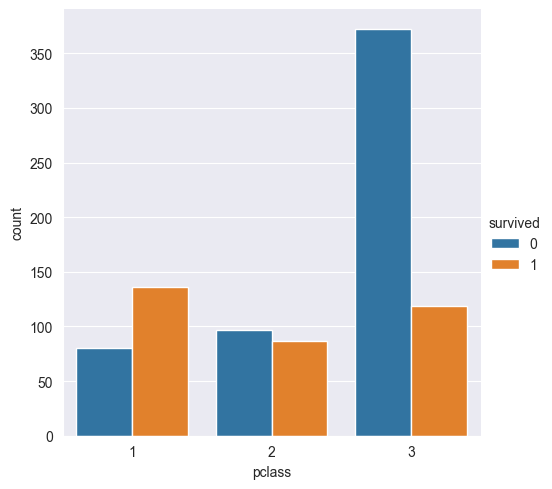

In [10]:
sns.catplot(data=data, x="pclass", hue="survived", kind="count")
plt.show()

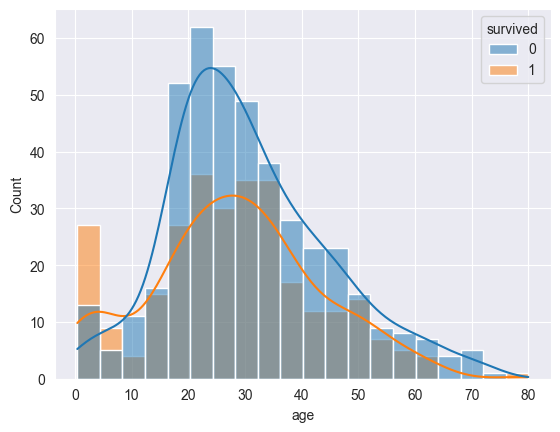

In [13]:
sns.histplot(data=data, x="age", kde=True, hue="survived")
plt.show()

In [14]:
data["who"].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

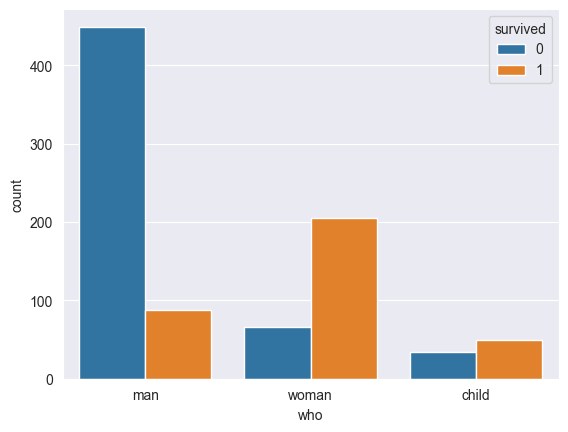

In [16]:
sns.countplot(data=data, x="who", hue="survived")
plt.show()

In [17]:
#feature engineering

In [18]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [19]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [20]:
data.shape

(891, 15)

In [21]:
data = data.drop(["deck", "embark_town", "alive"], axis=1)

In [22]:
data.isnull().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
alone           0
dtype: int64

In [23]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
data["age"] = data["age"].fillna(data["age"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

In [25]:
data["embarked"].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [26]:
data.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alone         0
dtype: int64

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    object  
 3   age         891 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    891 non-null    object  
 8   class       891 non-null    category
 9   who         891 non-null    object  
 10  adult_male  891 non-null    bool    
 11  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(3)
memory usage: 65.5+ KB


In [28]:
data["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [29]:
data["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [30]:
data["embarked"].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [31]:
data["who"].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [32]:
data["alone"]

0      False
1      False
2       True
3      False
4       True
       ...  
886     True
887     True
888    False
889     True
890     True
Name: alone, Length: 891, dtype: bool

In [33]:
data["adult_male"] = data["adult_male"].astype(int)
data["alone"] = data["alone"].astype(int)

In [34]:
data["alone"]

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: alone, Length: 891, dtype: int64

In [35]:
X = data.drop("survived", axis=1)
y = data["survived"]

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [40]:
categorical_columns = ["sex", "class", "embarked", "who"]

prepocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_columns),
], remainder="passthrough"
)

X_train = prepocessor.fit_transform(X_train)
X_test = prepocessor.transform(X_test)

In [41]:
encoded_columns = prepocessor.get_feature_names_out()

In [42]:
X_train = pd.DataFrame(X_train, columns=encoded_columns)
X_test = pd.DataFrame(X_test, columns=encoded_columns)

In [43]:
X_train

,cat__sex_male,cat__class_Second,cat__class_Third,cat__embarked_Q,cat__embarked_S,cat__who_man,cat__who_woman,remainder__pclass,remainder__age,remainder__sibsp,remainder__parch,remainder__fare,remainder__adult_male,remainder__alone
0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,27.0,0.0,0.0,7.8958,1.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,17.0,0.0,0.0,10.5000,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,28.0,0.0,0.0,0.0000,1.0,1.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,26.0,0.0,0.0,8.0500,1.0,1.0
4,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,43.0,0.0,0.0,8.0500,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,28.0,0.0,0.0,7.8958,1.0,1.0
664,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,19.0,0.0,0.0,30.0000,0.0,1.0
665,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,48.0,1.0,0.0,76.7292,1.0,0.0
666,1.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,18.0,0.0,0.0,11.5000,1.0,1.0


In [44]:
#pip install ligthgbm

In [45]:
import lightgbm as lgb

In [46]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [47]:
clf = lgb.LGBMClassifier(verbose=-1, n_jobs=-1)
clf.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [48]:
y_pred = clf.predict(X_test)

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7892376681614349
[[104  23]
 [ 24  72]]
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       127
           1       0.76      0.75      0.75        96

    accuracy                           0.79       223
   macro avg       0.79      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223



In [54]:
importances = clf.feature_importances_

feature_names = X_train.columns
feature_importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importances,
    }
).sort_values(by="Importance", ascending=False)

In [55]:
feature_importance

,Feature,Importance
11,remainder__fare,1132
8,remainder__age,865
4,cat__embarked_S,81
10,remainder__parch,77
9,remainder__sibsp,65
0,cat__sex_male,60
2,cat__class_Third,51
13,remainder__alone,41
1,cat__class_Second,41
6,cat__who_woman,36


In [62]:
# hyperparameter tuning
# https://lightgbm.readthedocs.io/en/latest/Parameters.html
# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html

from sklearn.model_selection import RandomizedSearchCV

In [61]:
lgb_model = lgb.LGBMClassifier(verbose=-1)

In [63]:
params = {
    "n_estimators": [100, 300, 500, 1000],
    "max_depth": [3, 5, 7, None],
    "learning_rate": [0.01, 0.05, 0.1, 0.3],
    "num_leaves": [16, 32, 15, 63, 127],
    "min_child_samples": [10,20,30],
    "subsample": [0.6,0.8, 1.0],
    "colsample_bytree": [0.6,0.8, 1.0],
}

In [64]:
rscv = RandomizedSearchCV(estimator=lgb_model,param_distributions=params, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)

In [65]:
rscv.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,LGBMClassifier(verbose=-1)
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [66]:
rscv.best_params_

{'subsample': 0.8,
 'num_leaves': 15,
 'n_estimators': 300,
 'min_child_samples': 10,
 'max_depth': None,
 'learning_rate': 0.01,
 'colsample_bytree': 0.8}

In [67]:
y_pred = rscv.predict(X_test)

In [68]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8385650224215246
[[112  15]
 [ 21  75]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       127
           1       0.83      0.78      0.81        96

    accuracy                           0.84       223
   macro avg       0.84      0.83      0.83       223
weighted avg       0.84      0.84      0.84       223



In [69]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7982062780269058
[[109  18]
 [ 27  69]]
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       127
           1       0.79      0.72      0.75        96

    accuracy                           0.80       223
   macro avg       0.80      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223



In [70]:
param_grids = {
    "n_estimators": [100, 300, 500, 1000],
    "max_depth": [3, 5, 7, None],
    "learning_rate": [0.01, 0.05, 0.1, 0.3],
    "colsample_bytree": [0.6,0.8, 1.0],
}

In [71]:
rscv = RandomizedSearchCV(estimator=XGBClassifier(), param_distributions=param_grids, cv=5, scoring="accuracy", n_jobs=-1)

In [72]:
rscv.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 300, ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [73]:
y_pred = rscv.predict(X_test)

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8475336322869955
[[113  14]
 [ 20  76]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       127
           1       0.84      0.79      0.82        96

    accuracy                           0.85       223
   macro avg       0.85      0.84      0.84       223
weighted avg       0.85      0.85      0.85       223

